<a href="https://colab.research.google.com/github/sanjivinicarmel/AgriDataAnalysis2016/blob/main/BiLSTM_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 14: Fake Job Posting Detection using BiLSTM

**Goal:** Detect whether a job advertisement is genuine or fraudulent using NLP and a small BiLSTM model.

The project brief specifies the **Fake Job Postings Dataset (Kaggle)**, **BiLSTM**, **NLP**, **binary classification**, and **fraud detection**.




In [1]:

!pip install -q kaggle tensorflow pandas scikit-learn matplotlib

In [2]:

from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [3]:
import os

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

# For Colab, kaggle.json is uploaded to the current directory.
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle authentication file configured.")

Kaggle authentication file configured.


In [4]:
DATASET_ID = "shivamb/real-or-fake-fake-jobposting-prediction"
DOWNLOAD_DIR = "kaggle_data"

os.makedirs(DOWNLOAD_DIR, exist_ok=True)

!kaggle datasets download -d shivamb/real-or-fake-fake-jobposting-prediction -p kaggle_data

Dataset URL: https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction
License(s): CC0-1.0
100% 16.1M/16.1M [00:01<00:00, 15.8MB/s]



In [5]:
import zipfile
from pathlib import Path

zip_files = list(Path(DOWNLOAD_DIR).glob('*.zip'))
print("Downloaded ZIP files:", zip_files)

with zipfile.ZipFile(zip_files[0], 'r') as z:
    z.extractall(DOWNLOAD_DIR)

print("Dataset extracted successfully.")

Downloaded ZIP files: [PosixPath('kaggle_data/real-or-fake-fake-jobposting-prediction.zip')]
Dataset extracted successfully.


## 7. Find and load the CSV

We search automatically for `fake_job_postings.csv`

In [7]:
csv_files = list(Path(DOWNLOAD_DIR).rglob('fake_job_postings.csv'))
import pandas as pd

if not csv_files:
    raise FileNotFoundError("fake_job_postings.csv was not found. Check the Kaggle download step.")

CSV_PATH = csv_files[0]
df = pd.read_csv(CSV_PATH)

print("CSV:", CSV_PATH)
print("Dataset shape:", df.shape)
print(df.head(3))

CSV: kaggle_data/fake_job_postings.csv
Dataset shape: (17880, 18)
   job_id                                      title          location  \
0       1                           Marketing Intern  US, NY, New York   
1       2  Customer Service - Cloud Video Production    NZ, , Auckland   
2       3    Commissioning Machinery Assistant (CMA)     US, IA, Wever   

  department salary_range                                    company_profile  \
0  Marketing          NaN  We're Food52, and we've created a groundbreaki...   
1    Success          NaN  90 Seconds, the worlds Cloud Video Production ...   
2        NaN          NaN  Valor Services provides Workforce Solutions th...   

                                         description  \
0  Food52, a fast-growing, James Beard Award-winn...   
1  Organised - Focused - Vibrant - Awesome!Do you...   
2  Our client, located in Houston, is actively se...   

                                        requirements  \
0  Experience with content manageme

## 8. Understand the target variable

The fraudulent column is our target:

- **0 → Genuine job posting**
- **1 → Fraudulent/fake job posting**

This makes the task a **binary classification problem**.

In [8]:
print(df['fraudulent'].value_counts())
print("\n0 = genuine, 1 = fraudulent")

fraudulent
0    17014
1      866
Name: count, dtype: int64

0 = genuine, 1 = fraudulent


## 9. Prepare the text

A job posting contains several useful text fields. We combine them into one text document.

Missing values are replaced by empty strings so they do not cause errors.

In [9]:
text_columns = [
    'title', 'company_profile', 'description',
    'requirements', 'benefits'
]

df['text'] = df[text_columns].fillna('').agg(' '.join, axis=1)
df = df[df['text'].str.strip() != ''].copy()

X = df['text'].values
y = df['fraudulent'].astype(int).values

print("Usable postings:", len(df))

Usable postings: 17880


## 10. Split training and validation data

**Training data:** used to learn patterns.

**Validation data:** used to check performance on unseen postings.

stratify=y keeps the genuine/fraudulent class proportion similar in both sets.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", len(X_train))
print("Validation:", len(X_val))

Training: 14304
Validation: 3576


## 11. Tokenization: words → numbers

A neural network cannot directly process words such as engineer or salary.

The tokenizer creates a vocabulary and converts each word into an integer ID.

Example:

data scientist needed → [25, 81, 14]

We use only the most frequent 10,000 words to keep the model small.

In [11]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE = 10000
MAX_LEN = 150

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)

print("Example token sequence:", X_train_seq[0][:15])

Example token sequence: [463, 541, 1219, 832, 359, 605, 520, 433, 7, 3458, 9, 4, 1439, 1122, 5]


## 12. Padding: make all text the same length

Job descriptions have different lengths. Neural networks work more easily when every input has the same shape.

MAX_LEN = 150 means every posting becomes 150 tokens long.

- Shorter text → zeros are added.
- Longer text → extra tokens are cut off.

In [12]:
X_train_pad = pad_sequences(
    X_train_seq, maxlen=MAX_LEN,
    padding='post', truncating='post'
)

X_val_pad = pad_sequences(
    X_val_seq, maxlen=MAX_LEN,
    padding='post', truncating='post'
)

print("Training shape:", X_train_pad.shape)
print("Validation shape:", X_val_pad.shape)

Training shape: (14304, 150)
Validation shape: (3576, 150)


## 13. Build a small BiLSTM model

Architecture:

**Embedding → BiLSTM → Dropout → Sigmoid**

**Embedding:** changes word IDs into small numerical vectors.

**BiLSTM:** reads the sequence in both directions, so it can use context from words before and after a word.

**Dropout:** reduces overfitting.

**Sigmoid:** gives a probability between 0 and 1 for the fraudulent class.

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout

model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=32),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 14. Compile the model

This is binary classification, so:

- **Binary cross-entropy:** measures prediction error.
- **Adam:** updates the model weights.
- **Accuracy:** percentage of correct predictions.

In [14]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 15. Train and validate

We use only **5 epochs** and a small BiLSTM

After every epoch, Keras reports both training and validation performance.

In [15]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
447/447 ━━━━━━━━━━━━━━━━━━━━ 47s 95ms/step - accuracy: 0.9629 - loss: 0.1446 - val_accuracy: 0.9849 - val_loss: 0.0564
Epoch 2/5
447/447 ━━━━━━━━━━━━━━━━━━━━ 41s 91ms/step - accuracy: 0.9876 - loss: 0.0420 - val_accuracy: 0.9855 - val_loss: 0.0469
Epoch 3/5
447/447 ━━━━━━━━━━━━━━━━━━━━ 41s 91ms/step - accuracy: 0.9928 - loss: 0.0257 - val_accuracy: 0.9855 - val_loss: 0.0524
Epoch 4/5
447/447 ━━━━━━━━━━━━━━━━━━━━ 41s 92ms/step - accuracy: 0.9962 - loss: 0.0118 - val_accuracy: 0.9863 - val_loss: 0.0600
Epoch 5/5
447/447 ━━━━━━━━━━━━━━━━━━━━ 41s 92ms/step - accuracy: 0.9976 - loss: 0.0086 - val_accuracy: 0.9871 - val_loss: 0.0500


## 16. Training vs validation accuracy

If training accuracy increases but validation accuracy stops improving, the model may be **overfitting**.

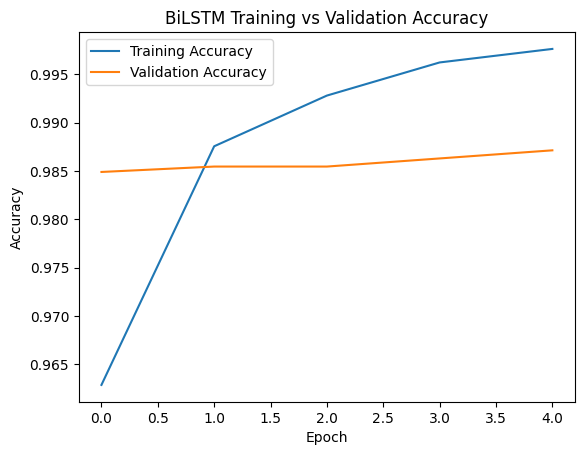

In [16]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('BiLSTM Training vs Validation Accuracy')
plt.legend()
plt.show()

Training: 96.3% → 98.8% → 99.3% → 99.6% → 99.8%

Validation: 98.5% → 98.5% → 98.5% → 98.6% → 98.7%

Training accuracy keeps increasing substantially, while  validation accuracy almost stops increasing

One important point:

Don't try to make the blue and orange lines artificially close.

The goal isn't:

"Blue and orange must touch."

The goal is:

"The model should perform well on unseen data, and the gap between training and validation performance should not become excessively large."

## 17. Training vs validation loss

Loss represents how wrong the model's predictions are. Lower is generally better.

A validation loss that starts increasing while training loss keeps decreasing can indicate overfitting.

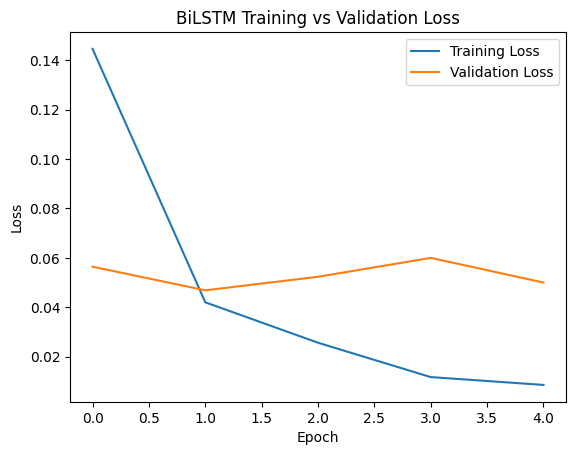

In [17]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('BiLSTM Training vs Validation Loss')
plt.legend()
plt.show()

## 18. Predict a new job posting

The new text must go through the **same tokenization and padding steps** used during training.

If the predicted probability is ≥ 0.5, we label it as fraudulent.

In [18]:
new_job = [
    "Work from home. No experience required. Pay a registration fee and send your bank details to start immediately."
]

new_seq = tokenizer.texts_to_sequences(new_job)
new_pad = pad_sequences(
    new_seq, maxlen=MAX_LEN,
    padding='post', truncating='post'
)

probability = model.predict(new_pad, verbose=0)[0][0]

print(f"Fraud probability: {probability:.2%}")
print("Prediction:", "FAKE / FRAUDULENT" if probability >= 0.5 else "GENUINE")

Fraud probability: 62.29%
Prediction: FAKE / FRAUDULENT


## 19. understand


**Important:** Because fake postings are much fewer than genuine postings in this dataset, accuracy alone can be misleading. A complete fraud-detection project should also examine precision, recall and F1-score.